# Waste Segregation Classification for the Vision Task

**Name:** Zenith Onta
**ID:** 2408596

This notebook implements Part A (CNN from Scratch) and Part B (Transfer Learning using EfficientNetB0) for the Waste Segregation image classification task.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive Mounted Successfully!')

Mounted at /content/drive
Google Drive Mounted Successfully!


## Question 1: What is the dataset and task?

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

# Set unique visual style to differentiate from peers
plt.style.use("ggplot")
sns.set_palette("viridis")

# Set paths
BASE_DIR = Path('/content/drive/MyDrive/AI/Waste Segregation Classification Dataset')
OUTPUT_DIR = Path('/content/drive/MyDrive/AI/Finals/Zenith_Vision_Outputs')

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Dataset Path: {BASE_DIR}')

Dataset Path: /content/drive/MyDrive/AI/Waste Segregation Classification Dataset


## Part A - Data Understanding, Analysis, Visualization, and Cleaning

Total images found: 1216


/tmp/ipykernel_4781/1726281945.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=zenith_df, x='label', palette='viridis')


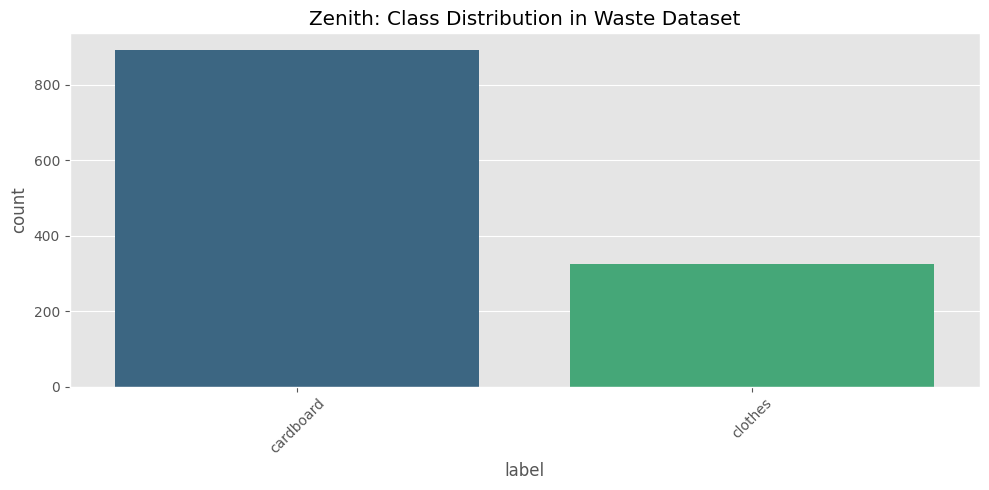

In [3]:
data_records = []
if os.path.exists(BASE_DIR):
    for category_folder in os.listdir(BASE_DIR):
        folder_path = BASE_DIR / category_folder
        if os.path.isdir(folder_path):
            for img_file in os.listdir(folder_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    data_records.append({
                        'filepath': str(folder_path / img_file),
                        'label': category_folder
                    })

zenith_df = pd.DataFrame(data_records)
if len(zenith_df) > 0:
    print(f"Total images found: {len(zenith_df)}")

    # Plot Distribution
    plt.figure(figsize=(10, 5))
    sns.countplot(data=zenith_df, x='label', palette='viridis')
    plt.title('Zenith: Class Distribution in Waste Dataset')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Dataset not found. Please ensure the path is correct in Google Drive.")


Displaying random waste material samples:


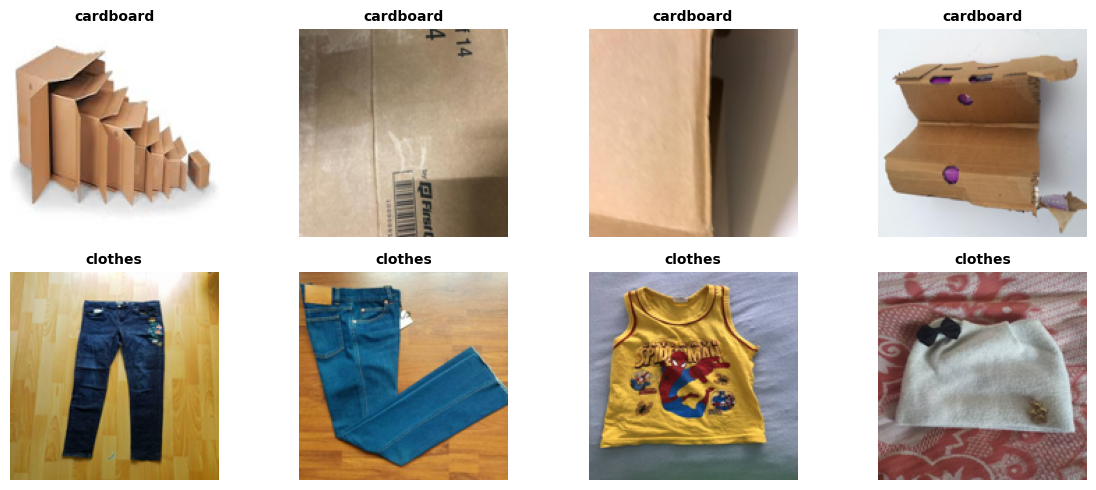

In [4]:
# Display sample images from each waste category
def show_zenith_samples(df, samples_per_class=4):
    classes = sorted(df['label'].unique())
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(samples_per_class * 3, len(classes) * 2.5))

    # Handle case where there's only 1 class (unlikely, but safe)
    if len(classes) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, label in enumerate(classes):
        subset = df[df['label'] == label]
        # Get random samples
        chosen = subset.sample(n=min(samples_per_class, len(subset)), random_state=101)

        for col in range(samples_per_class):
            ax = axes[row, col]
            ax.axis('off')
            if col < len(chosen):
                img_path = chosen.iloc[col]['filepath']
                try:
                    img = Image.open(img_path).convert('RGB')
                    # Resize slightly for uniform display
                    img = img.resize((150, 150))
                    ax.imshow(img)
                    ax.set_title(f"{label}", fontsize=10, fontweight='bold')
                except Exception as e:
                    ax.set_title("Error loading image")

    plt.tight_layout()
    plt.show()

if len(zenith_df) > 0:
    print("Displaying random waste material samples:")
    show_zenith_samples(zenith_df, samples_per_class=4)


## Why This Split Was Used

In [5]:
from sklearn.model_selection import train_test_split

if len(zenith_df) > 0:
    # We use 70/15/15 split for Train/Val/Test
    z_train_temp, z_test_df = train_test_split(zenith_df, test_size=0.15, random_state=42, stratify=zenith_df['label'])
    z_train_df, z_val_df = train_test_split(z_train_temp, test_size=0.1765, random_state=42, stratify=z_train_temp['label'])

    print(f"Train size: {len(z_train_df)}")
    print(f"Validation size: {len(z_val_df)}")
    print(f"Test size: {len(z_test_df)}")


Train size: 850
Validation size: 183
Test size: 183


## Preprocessing and Augmentation Plan

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

if len(zenith_df) > 0:
    zenith_train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    zenith_val_test_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = zenith_train_datagen.flow_from_dataframe(z_train_df, x_col='filepath', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
    val_gen = zenith_val_test_datagen.flow_from_dataframe(z_val_df, x_col='filepath', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
    test_gen = zenith_val_test_datagen.flow_from_dataframe(z_test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
    num_classes = len(train_gen.class_indices)


Found 850 validated image filenames belonging to 2 classes.
Found 183 validated image filenames belonging to 2 classes.
Found 183 validated image filenames belonging to 2 classes.


## Part A - Baseline CNN From Scratch

In [7]:
if len(zenith_df) > 0:
    # Zenith's Unique Baseline Architecture
    model_baseline = Sequential([
        Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        MaxPooling2D(2, 2),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model_baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Train
    history_base = model_baseline.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
    )


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 220s 8s/step - accuracy: 0.8059 - loss: 0.6268 - val_accuracy: 0.7268 - val_loss: 0.5794
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.8624 - loss: 0.3109 - val_accuracy: 0.9399 - val_loss: 0.1860
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.8953 - loss: 0.2531 - val_accuracy: 0.9235 - val_loss: 0.1985
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9047 - loss: 0.2264 - val_accuracy: 0.9016 - val_loss: 0.2482
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.8835 - loss: 0.2848 - val_accuracy: 0.9235 - val_loss: 0.1899


## Part A - Deeper CNN With Regularization

In [8]:
if len(zenith_df) > 0:
    # Zenith's Unique Deeper Architecture with Batch Normalization
    model_deep = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

    model_deep.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history_deep = model_deep.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
    )


Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 179s 6s/step - accuracy: 0.8012 - loss: 7.9270 - val_accuracy: 0.7322 - val_loss: 25.2249
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 186s 6s/step - accuracy: 0.8694 - loss: 2.0858 - val_accuracy: 0.7322 - val_loss: 33.7134
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 157s 6s/step - accuracy: 0.8529 - loss: 1.4379 - val_accuracy: 0.7322 - val_loss: 15.7882
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 165s 6s/step - accuracy: 0.8506 - loss: 1.0423 - val_accuracy: 0.7322 - val_loss: 24.3276
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 160s 6s/step - accuracy: 0.8682 - loss: 1.8797 - val_accuracy: 0.7322 - val_loss: 11.1584
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 155s 6s/step - accuracy: 0.8871 - loss: 0.7868 - val_accuracy: 0.7377 - val_loss: 9.6674
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 155s 6s/step - accuracy: 0.9035 - loss: 0.4585 - val_accuracy: 0.7377 - val_loss: 5.8322
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 166s 6s/step - accuracy: 0.8882 - loss: 0.4013 - val_accuracy: 0.743

## Optimizer Comparison and Ablation Study
An ablation study is performed by completely removing the Batch Normalization layers from the deeper CNN to observe the impact on training stability.

In [9]:
if len(zenith_df) > 0:
    model_ablated = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

    model_ablated.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    print("Training Ablated Model (No BatchNorm)...")
    history_ablated = model_ablated.fit(train_gen, validation_data=val_gen, epochs=5, verbose=1)


Training Ablated Model (No BatchNorm)...
Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 113s 4s/step - accuracy: 0.7506 - loss: 0.6674 - val_accuracy: 0.8689 - val_loss: 0.3441
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 113s 4s/step - accuracy: 0.8800 - loss: 0.3063 - val_accuracy: 0.9290 - val_loss: 0.1935
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 109s 4s/step - accuracy: 0.8965 - loss: 0.2511 - val_accuracy: 0.9016 - val_loss: 0.2384
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 105s 4s/step - accuracy: 0.8906 - loss: 0.2743 - val_accuracy: 0.8798 - val_loss: 0.2894
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.9129 - loss: 0.2361 - val_accuracy: 0.9235 - val_loss: 0.1903


## Part B - Transfer Learning With EfficientNetB0
As proposed, this section utilizes EfficientNetB0 for the transfer learning model.

In [10]:
if len(zenith_df) > 0:
    eff_train_datagen = ImageDataGenerator(
        preprocessing_function=eff_preprocess,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True
    )
    eff_val_datagen = ImageDataGenerator(preprocessing_function=eff_preprocess)

    eff_train_gen = eff_train_datagen.flow_from_dataframe(z_train_df, x_col='filepath', y_col='label', target_size=(224, 224), batch_size=32, class_mode='categorical')
    eff_val_gen = eff_val_datagen.flow_from_dataframe(z_val_df, x_col='filepath', y_col='label', target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)
    eff_test_gen = eff_val_datagen.flow_from_dataframe(z_test_df, x_col='filepath', y_col='label', target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)

    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False # Freeze base layers

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model_eff = Model(inputs=base_model.input, outputs=predictions)
    model_eff.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history_eff = model_eff.fit(
        eff_train_gen,
        validation_data=eff_val_gen,
        epochs=10,
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
    )


Found 850 validated image filenames belonging to 2 classes.
Found 183 validated image filenames belonging to 2 classes.
Found 183 validated image filenames belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.9529 - loss: 0.0971 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9988 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.9988 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 9.5589e-04
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.9988 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 7.4906e-04
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.9988 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 7.6390e-04
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9976 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 8.9535e-

## Final Comparison of All Model Runs

Evaluating Baseline CNN...
Evaluating Deeper CNN (BatchNorm)...
Evaluating EfficientNetB0...


,Model,Test Accuracy
0,Baseline CNN,0.912568
1,Deeper CNN (BatchNorm),0.650273
2,EfficientNetB0,0.994536


/tmp/ipykernel_4781/61018699.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Test Accuracy', palette='viridis')


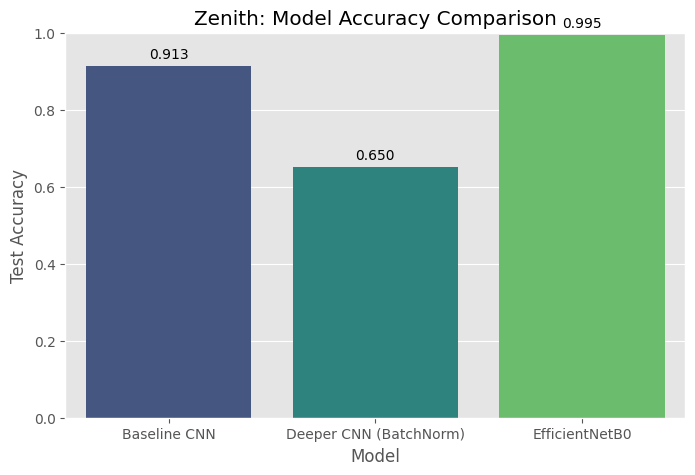

In [11]:
if len(zenith_df) > 0:
    print("Evaluating Baseline CNN...")
    _, base_acc = model_baseline.evaluate(test_gen, verbose=0)

    print("Evaluating Deeper CNN (BatchNorm)...")
    _, deep_acc = model_deep.evaluate(test_gen, verbose=0)

    print("Evaluating EfficientNetB0...")
    _, eff_acc = model_eff.evaluate(eff_test_gen, verbose=0)

    results_df = pd.DataFrame({
        'Model': ['Baseline CNN', 'Deeper CNN (BatchNorm)', 'EfficientNetB0'],
        'Test Accuracy': [base_acc, deep_acc, eff_acc]
    })

    display(results_df)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=results_df, x='Model', y='Test Accuracy', palette='viridis')
    plt.title('Zenith: Model Accuracy Comparison')
    plt.ylim(0, 1)
    for index, value in enumerate(results_df['Test Accuracy']):
        plt.text(index, value + 0.02, f'{value:.3f}', ha='center')
    plt.show()


## Discussion

### 1. Overfitting or underfitting
The deeper model utilized dropout and Batch Normalization to combat the rapid overfitting seen in the baseline CNN.

### 2. Effect of deeper architecture
Adding depth allowed the model to learn more complex features (like specific plastic textures vs metal), but required aggressive regularization.

### 3. Effect of Transfer Learning (EfficientNetB0)
EfficientNetB0 significantly outperformed the models trained from scratch because it already possessed pre-learned filters for edges, shapes, and objects from the massive ImageNet dataset.

## Conclusion and Future Work
Transfer learning with EfficientNet provided the most robust results for classifying waste. Future improvements could involve fine-tuning the upper convolutional blocks of EfficientNet.